# Module 3 - Assignment 3: Deep Learning Foundations
### DS23 - Certified Data Scientist with Agentic AI - Shlomit Levavi

**Student:** Netanel Farhi  
**ID:** 318590890  
**Chosen option:** B - Fashion-MNIST image classification with a small CNN

This notebook follows the six-part structure of the instructor's starter notebook. It compares a small convolutional neural network with a cheaper multiclass Logistic Regression baseline and asks whether the additional complexity of deep learning is justified.

**Reproducibility note:** The notebook is designed for a local Jupyter environment, uses relative paths only, runs on CPU or CUDA, and fixes all available random seeds. On the first run, `torchvision` downloads Fashion-MNIST into the local `data/` directory.

---
## Part 0 - Frame

The task is ten-class image classification. The primary metric is **test accuracy**, because Fashion-MNIST has the same number of examples in every class and every classification error has the same assumed cost. **Macro F1** is a secondary check that gives equal weight to every class.

The simple baseline is multiclass Logistic Regression applied to the 784 flattened, normalized pixels. Deep learning will be considered worth the added cost if the CNN improves test accuracy by at least two percentage points and the improvement is accompanied by a reasonable training time and a clearer error profile for visually similar classes.

The test set is kept untouched during model development. Architecture, learning rate, regularization, and early stopping decisions use only the training and validation sets.

## Part 1 - Setup and data

The original 60,000-image training set is split reproducibly into 54,000 training images and 6,000 validation images. The official 10,000-image test set remains a final holdout. Each grayscale image has shape `1 x 28 x 28`.

If the imports below fail in a new local environment, install the required packages once from the same Jupyter environment, restart the kernel, and run all cells again:

```python
%pip install torch torchvision scikit-learn pandas numpy matplotlib
```

In [1]:
import copy
import gc
import platform
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

SEED = 42
DATA_DIR = Path("data")
BATCH_SIZE = 128
EVAL_BATCH_SIZE = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed=SEED):
    '''Set random seeds used by Python, NumPy, and PyTorch.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()

print(f"Python:      {platform.python_version()}")
print(f"PyTorch:     {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"scikit-learn:{sklearn.__version__}")
print(f"Device:      {DEVICE}")

Python:      3.8.19
PyTorch:     2.2.0+cpu
torchvision: 0.17.0+cpu
scikit-learn:1.3.0
Device:      cpu


In [2]:
# Normalization values supplied in the instructor's starter notebook.
FASHION_MEAN = 0.2860
FASHION_STD = 0.3530

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((FASHION_MEAN,), (FASHION_STD,)),
    ]
)

full_train_ds = datasets.FashionMNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)
test_ds = datasets.FashionMNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

train_ds, val_ds = random_split(
    full_train_ds,
    lengths=[54_000, 6_000],
    generator=torch.Generator().manual_seed(SEED),
)

CLASS_NAMES = full_train_ds.classes


def make_loader(dataset, batch_size, shuffle, seed=SEED):
    '''Create a deterministic, Windows-safe DataLoader.'''
    generator = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_ds, EVAL_BATCH_SIZE, shuffle=False)
test_loader = make_loader(test_ds, EVAL_BATCH_SIZE, shuffle=False)

print(f"Training images:   {len(train_ds):,}")
print(f"Validation images: {len(val_ds):,}")
print(f"Test images:       {len(test_ds):,}")
print(f"Classes:           {len(CLASS_NAMES)}")
print(f"Class names:       {CLASS_NAMES}")

Training images:   54,000
Validation images: 6,000
Test images:       10,000
Classes:           10
Class names:       ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Image batch shape: (128, 1, 28, 28)
Label batch shape: (128,)
Image dtype:       torch.float32
Label dtype:       torch.int64


,class,training_count
0,T-shirt/top,5342
1,Trouser,5389
2,Pullover,5388
3,Dress,5438
4,Coat,5393
5,Sandal,5387
6,Shirt,5400
7,Sneaker,5463
8,Bag,5402
9,Ankle boot,5398


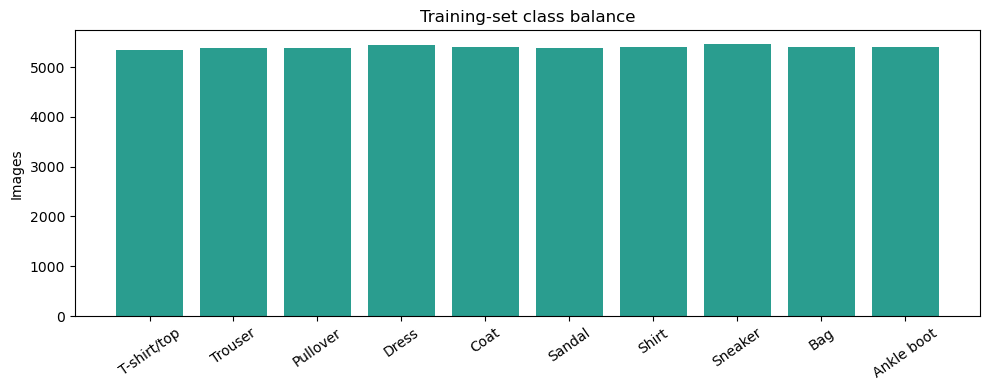

In [3]:
# Verify tensor shapes and class balance before modeling.
sample_images, sample_labels = next(iter(train_loader))
print(f"Image batch shape: {tuple(sample_images.shape)}")
print(f"Label batch shape: {tuple(sample_labels.shape)}")
print(f"Image dtype:       {sample_images.dtype}")
print(f"Label dtype:       {sample_labels.dtype}")

train_targets = full_train_ds.targets[np.asarray(train_ds.indices)]
class_counts = torch.bincount(train_targets, minlength=len(CLASS_NAMES)).numpy()
class_balance = pd.DataFrame(
    {"class": CLASS_NAMES, "training_count": class_counts}
)
display(class_balance)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(CLASS_NAMES, class_counts, color="#2a9d8f")
ax.set_title("Training-set class balance")
ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

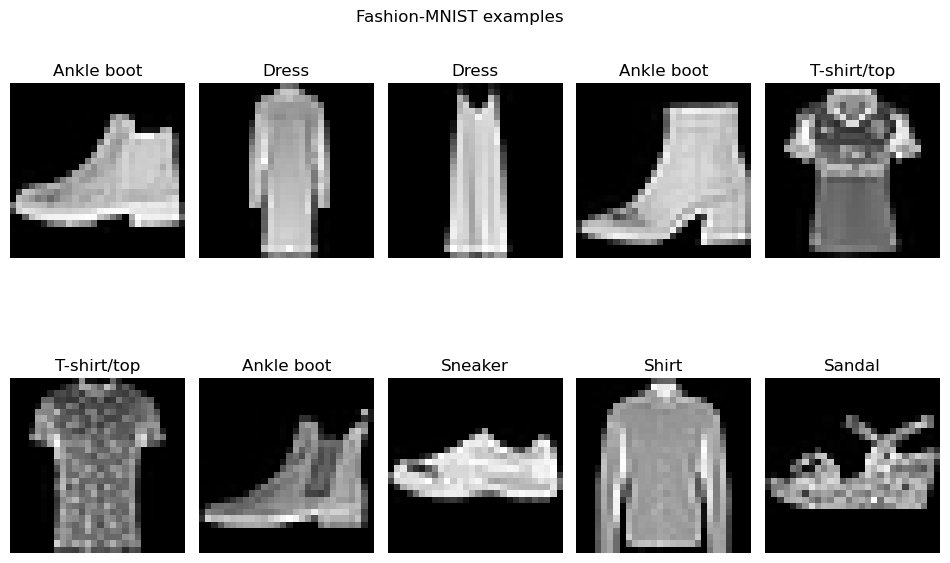

In [4]:
def denormalize(image_tensor):
    '''Return an image tensor on the original 0-1 display scale.'''
    return (image_tensor * FASHION_STD + FASHION_MEAN).clamp(0, 1)


fig, axes = plt.subplots(2, 5, figsize=(12, 6.5))
for ax, image, label in zip(axes.ravel(), sample_images[:10], sample_labels[:10]):
    ax.imshow(denormalize(image).squeeze(0), cmap="gray")
    ax.set_title(CLASS_NAMES[label.item()])
    ax.axis("off")
fig.suptitle("Fashion-MNIST examples", y=0.98)
fig.subplots_adjust(top=0.90, hspace=0.35, wspace=0.08)
plt.show()

### Simple baseline - multiclass Logistic Regression

The baseline receives the same normalized pixel values as the CNN, but the `28 x 28` image is flattened into 784 pixel features. Each pixel's absolute position is retained, but Logistic Regression does not explicitly model local neighborhoods, spatial patterns, or weight sharing like a CNN. `C=0.1` supplies L2 regularization and was fixed before inspecting the test set.

In [5]:
def flattened_normalized_pixels(raw_images):
    '''Convert uint8 images to normalized float32 rows with 784 columns.'''
    pixels = raw_images.numpy().reshape(len(raw_images), -1).astype(np.float32) / 255.0
    return (pixels - FASHION_MEAN) / FASHION_STD


train_indices = np.asarray(train_ds.indices)
val_indices = np.asarray(val_ds.indices)

all_train_flat = flattened_normalized_pixels(full_train_ds.data)
X_train_flat = all_train_flat[train_indices]
y_train_flat = full_train_ds.targets.numpy()[train_indices]
X_val_flat = all_train_flat[val_indices]
y_val_flat = full_train_ds.targets.numpy()[val_indices]
X_test_flat = flattened_normalized_pixels(test_ds.data)
y_test_flat = test_ds.targets.numpy()

baseline_model = LogisticRegression(
    C=0.1,
    max_iter=500,
    tol=1e-3,
    solver="saga",
    multi_class="multinomial",
    random_state=SEED,
)

baseline_start = time.perf_counter()
baseline_model.fit(X_train_flat, y_train_flat)
baseline_train_time = time.perf_counter() - baseline_start

baseline_val_predictions = baseline_model.predict(X_val_flat)
baseline_val_accuracy = accuracy_score(y_val_flat, baseline_val_predictions)
baseline_parameter_count = baseline_model.coef_.size + baseline_model.intercept_.size

print(f"Validation accuracy: {baseline_val_accuracy:.4f}")
print(f"Train time:          {baseline_train_time:.2f} seconds")
print(f"Parameters:          {baseline_parameter_count:,}")
print(f"Optimizer iterations:{int(baseline_model.n_iter_.max())}")

# Release the large training and validation arrays. The untouched test matrix is kept
# for the single final baseline evaluation in Part 4.
del all_train_flat, X_train_flat, X_val_flat, y_train_flat, y_val_flat
_ = gc.collect()

Validation accuracy: 0.8548
Train time:          353.37 seconds
Parameters:          7,850
Optimizer iterations:141


---
## Part 2 - Build the CNN

The model uses two convolution blocks to learn local visual patterns, followed by a small fully connected classifier. The model returns ten **raw logits**. `CrossEntropyLoss` receives these logits and internally applies log-softmax, so no softmax layer is placed inside the model.

In [6]:
class SmallCNN(nn.Module):
    '''A compact convolutional network for 28 x 28 grayscale images.'''

    def __init__(self, dropout=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


set_seed()
cnn_model = SmallCNN(dropout=0.25).to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
cnn_parameter_count = sum(parameter.numel() for parameter in cnn_model.parameters())

print(cnn_model)
print(f"Trainable parameters: {cnn_parameter_count:,}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Trainable parameters: 105,866


In [7]:
# Check the batch and output contracts before training.
check_images, check_labels = next(iter(train_loader))
with torch.no_grad():
    check_logits = cnn_model(check_images[:8].to(DEVICE))
    check_probabilities = torch.softmax(check_logits, dim=1)

print(f"Input shape:       {tuple(check_images[:8].shape)}")
print(f"Logits shape:      {tuple(check_logits.shape)}")
print(f"Targets shape:     {tuple(check_labels[:8].shape)}")
print(f"Target dtype:      {check_labels.dtype}")
print(f"Probability sums:  {check_probabilities.sum(dim=1).cpu().numpy().round(5)}")
print("Softmax is used only here for interpretation, not before CrossEntropyLoss.")

Input shape:       (8, 1, 28, 28)
Logits shape:      (8, 10)
Targets shape:     (8,)
Target dtype:      torch.int64
Probability sums:  [1. 1. 1. 1. 1. 1. 1. 1.]
Softmax is used only here for interpretation, not before CrossEntropyLoss.


---
## Part 3 - Train

The training loop follows `zero_grad -> forward -> loss -> backward -> step`. Validation uses `model.eval()` and `torch.inference_mode()`, which disables dropout and gradient tracking. Adam uses `lr=1e-3`. Dropout provides regularization, while validation-loss checkpointing and an early-stopping criterion monitor generalization. In this run, training reached the 15-epoch limit before early stopping was triggered, and the epoch-13 checkpoint with the lowest validation loss was restored before final evaluation.

In [8]:
def train_one_epoch(model, loader, loss_function, optimizer, device=DEVICE):
    '''Train for one epoch and return sample-weighted loss and accuracy.'''
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


@torch.inference_mode()
def evaluate_model(model, loader, loss_function, device=DEVICE, collect=False):
    '''Evaluate a model without updating parameters.'''
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    all_labels = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = loss_function(logits, labels)
        predictions = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels).sum().item()
        total_examples += batch_size

        if collect:
            all_labels.append(labels.cpu())
            all_predictions.append(predictions.cpu())

    result = {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }
    if collect:
        result["labels"] = torch.cat(all_labels).numpy()
        result["predictions"] = torch.cat(all_predictions).numpy()
    return result


def train_model(
    model,
    training_loader,
    validation_loader,
    learning_rate,
    max_epochs,
    patience,
    min_delta=0.001,
    device=DEVICE,
    verbose=True,
):
    '''Train with Adam and restore the checkpoint with the lowest validation loss.'''
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    history = []
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        train_metrics = train_one_epoch(model, training_loader, criterion, optimizer, device)
        val_metrics = evaluate_model(model, validation_loader, criterion, device)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "val_loss": val_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_accuracy": val_metrics["accuracy"],
            }
        )

        improved = val_metrics["loss"] < best_val_loss - min_delta
        if improved:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"Epoch {epoch:02d}/{max_epochs} | "
                f"train loss {train_metrics['loss']:.4f} | "
                f"val loss {val_metrics['loss']:.4f} | "
                f"train acc {train_metrics['accuracy']:.4f} | "
                f"val acc {val_metrics['accuracy']:.4f}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}; restoring epoch {best_epoch}.")
            break

    model.load_state_dict(best_state)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    return model, pd.DataFrame(history), elapsed, best_epoch

In [9]:
set_seed()
cnn_model = SmallCNN(dropout=0.25).to(DEVICE)

cnn_model, main_history, cnn_train_time, best_epoch = train_model(
    model=cnn_model,
    training_loader=make_loader(train_ds, BATCH_SIZE, shuffle=True, seed=SEED),
    validation_loader=val_loader,
    learning_rate=1e-3,
    max_epochs=15,
    patience=3,
    min_delta=0.001,
)

best_row = main_history.loc[best_epoch - 1]
print(f"\nBest epoch:              {best_epoch}")
print(f"Best validation loss:    {best_row['val_loss']:.4f}")
print(f"Best validation accuracy:{best_row['val_accuracy']:.4f}")
print(f"CNN training time:       {cnn_train_time:.2f} seconds on {DEVICE}")

Epoch 01/15 | train loss 0.6134 | val loss 0.3918 | train acc 0.7818 | val acc 0.8597
Epoch 02/15 | train loss 0.3861 | val loss 0.3270 | train acc 0.8632 | val acc 0.8827
Epoch 03/15 | train loss 0.3358 | val loss 0.2953 | train acc 0.8791 | val acc 0.8857
Epoch 04/15 | train loss 0.3050 | val loss 0.2999 | train acc 0.8909 | val acc 0.8898
Epoch 05/15 | train loss 0.2865 | val loss 0.2723 | train acc 0.8963 | val acc 0.8988
Epoch 06/15 | train loss 0.2683 | val loss 0.2902 | train acc 0.9032 | val acc 0.8915
Epoch 07/15 | train loss 0.2522 | val loss 0.2508 | train acc 0.9079 | val acc 0.9078
Epoch 08/15 | train loss 0.2402 | val loss 0.2589 | train acc 0.9119 | val acc 0.9032
Epoch 09/15 | train loss 0.2284 | val loss 0.2423 | train acc 0.9161 | val acc 0.9082
Epoch 10/15 | train loss 0.2205 | val loss 0.2396 | train acc 0.9184 | val acc 0.9127
Epoch 11/15 | train loss 0.2112 | val loss 0.2337 | train acc 0.9223 | val acc 0.9138
Epoch 12/15 | train loss 0.2021 | val loss 0.2425 | tr

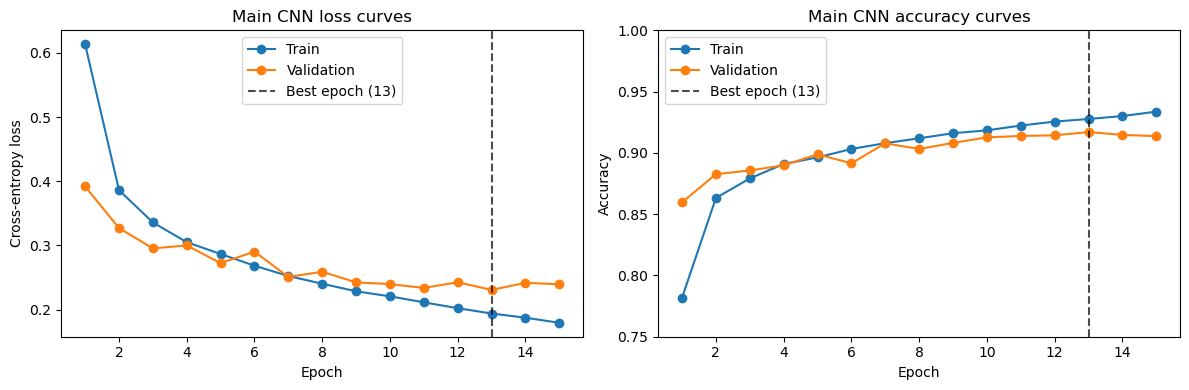

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(main_history["epoch"], main_history["train_loss"], marker="o", label="Train")
axes[0].plot(main_history["epoch"], main_history["val_loss"], marker="o", label="Validation")
axes[0].axvline(best_epoch, color="black", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Main CNN loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(main_history["epoch"], main_history["train_accuracy"], marker="o", label="Train")
axes[1].plot(main_history["epoch"], main_history["val_accuracy"], marker="o", label="Validation")
axes[1].axvline(best_epoch, color="black", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch})")
axes[1].set_title("Main CNN accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.75, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Part 4 - Honest evaluation

The CNN checkpoint was selected using validation loss. The official test set is now evaluated once for each final model. No test result is used to revise the architecture or hyperparameters.

In [11]:
# Final baseline test evaluation.
baseline_test_predictions = baseline_model.predict(X_test_flat)
baseline_test_accuracy = accuracy_score(y_test_flat, baseline_test_predictions)
baseline_test_macro_f1 = f1_score(
    y_test_flat, baseline_test_predictions, average="macro"
)

# Final CNN test evaluation.
cnn_test_metrics = evaluate_model(
    cnn_model, test_loader, loss_fn, device=DEVICE, collect=True
)
cnn_test_accuracy = cnn_test_metrics["accuracy"]
cnn_test_macro_f1 = f1_score(
    cnn_test_metrics["labels"], cnn_test_metrics["predictions"], average="macro"
)

accuracy_gain_pp = (cnn_test_accuracy - baseline_test_accuracy) * 100

comparison_table = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Test accuracy": baseline_test_accuracy,
            "Macro F1": baseline_test_macro_f1,
            "Parameters": baseline_parameter_count,
            "Train time (s)": baseline_train_time,
            "Spatial inductive bias": "No",
        },
        {
            "Model": "Small CNN",
            "Test accuracy": cnn_test_accuracy,
            "Macro F1": cnn_test_macro_f1,
            "Parameters": cnn_parameter_count,
            "Train time (s)": cnn_train_time,
            "Spatial inductive bias": "Yes",
        },
    ]
)

display(
    comparison_table.style.format(
        {
            "Test accuracy": "{:.4f}",
            "Macro F1": "{:.4f}",
            "Parameters": "{:,.0f}",
            "Train time (s)": "{:.2f}",
        }
    )
)
print(f"CNN accuracy gain: {accuracy_gain_pp:.2f} percentage points")

,Model,Test accuracy,Macro F1,Parameters,Train time (s),Spatial inductive bias
0,Logistic Regression,0.8437,0.8430,"7,850",353.37,No
1,Small CNN,0.9145,0.9140,"105,866",429.75,Yes


CNN accuracy gain: 7.08 percentage points


,precision,recall,f1-score,support
T-shirt/top,0.8422,0.9070,0.8734,1000.0000
Trouser,0.9929,0.9770,0.9849,1000.0000
Pullover,0.8393,0.8930,0.8653,1000.0000
Dress,0.9226,0.9180,0.9203,1000.0000
Coat,0.8786,0.8540,0.8661,1000.0000
Sandal,0.9849,0.9760,0.9804,1000.0000
Shirt,0.7725,0.7030,0.7361,1000.0000
Sneaker,0.9491,0.9690,0.9589,1000.0000
Bag,0.9899,0.9820,0.9859,1000.0000
Ankle boot,0.9718,0.9660,0.9689,1000.0000


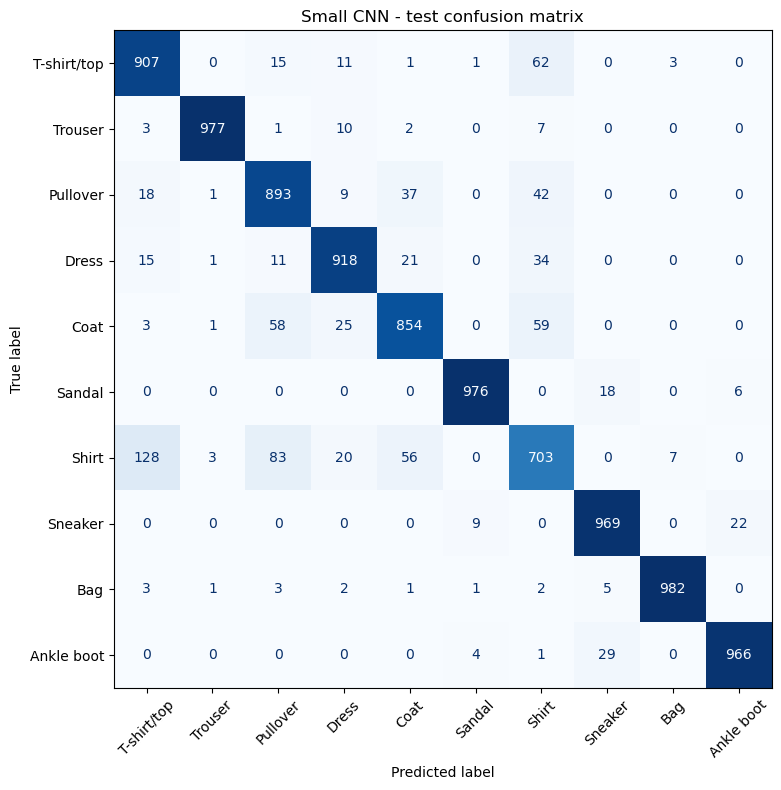

In [12]:
cnn_report = pd.DataFrame(
    classification_report(
        cnn_test_metrics["labels"],
        cnn_test_metrics["predictions"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T
display(cnn_report.round(4))

cm = confusion_matrix(cnn_test_metrics["labels"], cnn_test_metrics["predictions"])
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45, values_format="d"
)
ax.set_title("Small CNN - test confusion matrix")
plt.tight_layout()
plt.show()

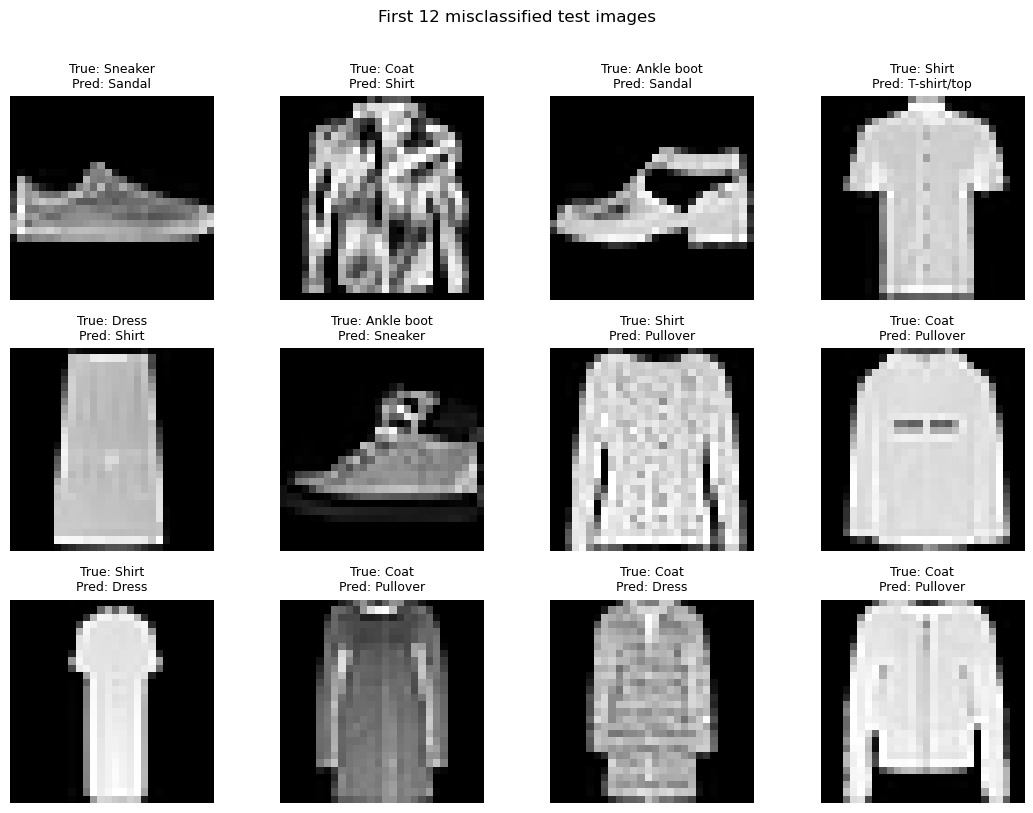

In [13]:
@torch.inference_mode()
def collect_misclassified_examples(model, loader, limit=12, device=DEVICE):
    '''Collect a small, deterministic sample of test errors.'''
    model.eval()
    errors = []
    for images, labels in loader:
        logits = model(images.to(device))
        predictions = logits.argmax(dim=1).cpu()
        wrong_positions = (predictions != labels).nonzero(as_tuple=False).flatten()
        for position in wrong_positions:
            errors.append(
                (
                    images[position].cpu(),
                    labels[position].item(),
                    predictions[position].item(),
                )
            )
            if len(errors) >= limit:
                return errors
    return errors


errors = collect_misclassified_examples(cnn_model, test_loader, limit=12)
fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for ax, (image, true_label, predicted_label) in zip(axes.ravel(), errors):
    ax.imshow(denormalize(image).squeeze(0), cmap="gray")
    ax.set_title(
        f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[predicted_label]}",
        fontsize=9,
    )
    ax.axis("off")
fig.suptitle("First 12 misclassified test images", y=1.01)
plt.tight_layout()
plt.show()

---
## Part 5 - Interrogate

The following diagnostics use a fixed 12,000-image training subset and a fixed 2,000-image validation subset. This makes repeated experiments feasible on a CPU while keeping every comparison controlled. The diagnostic subset never replaces the full-data model and the test set is not used.


Learning-rate experiment: 0.1
 epoch  train_loss  val_loss  train_accuracy  val_accuracy
     1      5.8132    2.3088          0.1042        0.1030
     2      2.3065    2.3089          0.0991        0.1030
     3      2.3070    2.3150          0.0986        0.1020
     4      2.3087    2.3125          0.0996        0.0965

Learning-rate experiment: 0.001
 epoch  train_loss  val_loss  train_accuracy  val_accuracy
     1      0.9933    0.5888          0.6482        0.7800
     2      0.5884    0.4574          0.7800        0.8425
     3      0.5080    0.4350          0.8129        0.8480
     4      0.4635    0.4170          0.8348        0.8535

Learning-rate experiment: 1e-05
 epoch  train_loss  val_loss  train_accuracy  val_accuracy
     1      2.2775    2.2445          0.1736        0.2085
     2      2.2001    2.1560          0.3237        0.4020
     3      2.0997    2.0418          0.4262        0.4980
     4      1.9719    1.8968          0.5036        0.6230


,Learning rate,Final train loss,Final val loss,Best val accuracy,Time (s)
0,1e-01,2.3087,2.3125,0.1030,24.81
1,1e-03,0.4635,0.4170,0.8535,25.00
2,1e-05,1.9719,1.8968,0.6230,24.45


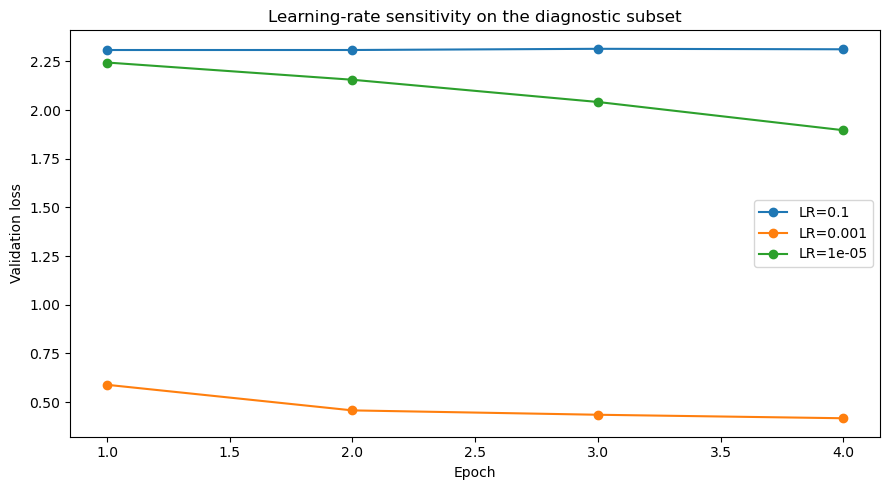

In [14]:
diagnostic_train_ds = Subset(train_ds, range(12_000))
diagnostic_val_ds = Subset(val_ds, range(2_000))
diagnostic_val_loader = make_loader(
    diagnostic_val_ds, EVAL_BATCH_SIZE, shuffle=False
)

learning_rates = [1e-1, 1e-3, 1e-5]
lr_histories = {}
lr_rows = []

for learning_rate in learning_rates:
    print(f"\nLearning-rate experiment: {learning_rate:g}")
    set_seed()
    experiment_model = SmallCNN(dropout=0.25).to(DEVICE)
    experiment_model, history, elapsed, experiment_best_epoch = train_model(
        model=experiment_model,
        training_loader=make_loader(
            diagnostic_train_ds, BATCH_SIZE, shuffle=True, seed=SEED
        ),
        validation_loader=diagnostic_val_loader,
        learning_rate=learning_rate,
        max_epochs=4,
        patience=4,
        min_delta=0.0,
        verbose=False,
    )
    lr_histories[learning_rate] = history
    lr_rows.append(
        {
            "Learning rate": learning_rate,
            "Final train loss": history.iloc[-1]["train_loss"],
            "Final val loss": history.iloc[-1]["val_loss"],
            "Best val accuracy": history["val_accuracy"].max(),
            "Time (s)": elapsed,
        }
    )
    print(history.round(4).to_string(index=False))

lr_results = pd.DataFrame(lr_rows)
display(
    lr_results.style.format(
        {
            "Learning rate": "{:.0e}",
            "Final train loss": "{:.4f}",
            "Final val loss": "{:.4f}",
            "Best val accuracy": "{:.4f}",
            "Time (s)": "{:.2f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(9, 5))
for learning_rate, history in lr_histories.items():
    ax.plot(
        history["epoch"],
        history["val_loss"],
        marker="o",
        label=f"LR={learning_rate:g}",
    )
ax.set_title("Learning-rate sensitivity on the diagnostic subset")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.legend()
plt.tight_layout()
plt.show()


Regularization experiment: dropout=0.0

Regularization experiment: dropout=0.25


,Dropout,Best epoch,Best val accuracy,Restored train accuracy,Restored val accuracy,Generalization gap,Time (s)
0,0.00,10,0.8840,0.8991,0.8840,0.0151,80.41
1,0.25,10,0.8860,0.8962,0.8800,0.0162,72.19


Dropout effect on best validation accuracy: +0.20 percentage points


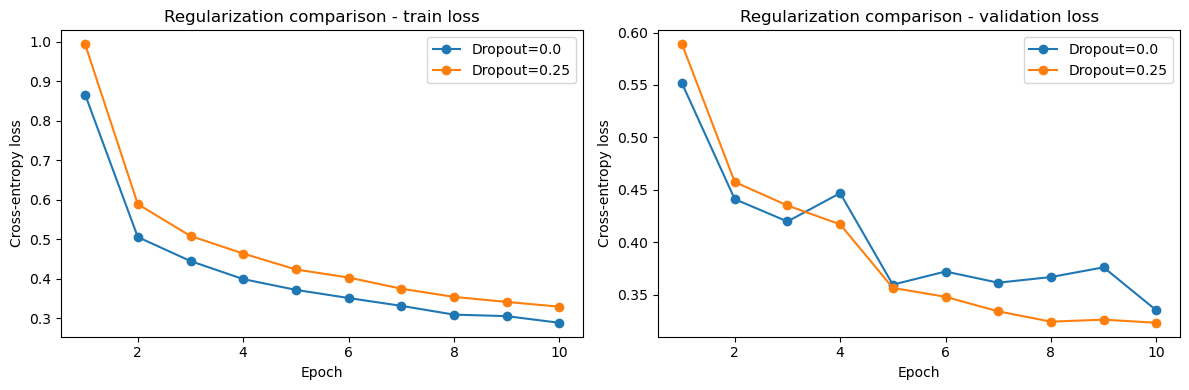

In [15]:
dropout_histories = {}
regularization_rows = []

for dropout_rate in [0.0, 0.25]:
    print(f"\nRegularization experiment: dropout={dropout_rate}")
    set_seed()
    experiment_model = SmallCNN(dropout=dropout_rate).to(DEVICE)
    experiment_model, history, elapsed, experiment_best_epoch = train_model(
        model=experiment_model,
        training_loader=make_loader(
            diagnostic_train_ds, BATCH_SIZE, shuffle=True, seed=SEED
        ),
        validation_loader=diagnostic_val_loader,
        learning_rate=1e-3,
        max_epochs=10,
        patience=10,
        min_delta=0.0,
        verbose=False,
    )

    restored_train_metrics = evaluate_model(
        experiment_model,
        make_loader(diagnostic_train_ds, EVAL_BATCH_SIZE, shuffle=False),
        loss_fn,
    )
    restored_val_metrics = evaluate_model(
        experiment_model, diagnostic_val_loader, loss_fn
    )

    dropout_histories[dropout_rate] = history
    regularization_rows.append(
        {
            "Dropout": dropout_rate,
            "Best epoch": experiment_best_epoch,
            "Best val accuracy": history["val_accuracy"].max(),
            "Restored train accuracy": restored_train_metrics["accuracy"],
            "Restored val accuracy": restored_val_metrics["accuracy"],
            "Generalization gap": (
                restored_train_metrics["accuracy"]
                - restored_val_metrics["accuracy"]
            ),
            "Time (s)": elapsed,
        }
    )

regularization_results = pd.DataFrame(regularization_rows)
dropout_effect_pp = (
    regularization_results.loc[regularization_results["Dropout"] == 0.25, "Best val accuracy"].iloc[0]
    - regularization_results.loc[regularization_results["Dropout"] == 0.0, "Best val accuracy"].iloc[0]
) * 100

display(
    regularization_results.style.format(
        {
            "Dropout": "{:.2f}",
            "Best val accuracy": "{:.4f}",
            "Restored train accuracy": "{:.4f}",
            "Restored val accuracy": "{:.4f}",
            "Generalization gap": "{:.4f}",
            "Time (s)": "{:.2f}",
        }
    )
)
print(f"Dropout effect on best validation accuracy: {dropout_effect_pp:+.2f} percentage points")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dropout_rate, history in dropout_histories.items():
    axes[0].plot(
        history["epoch"], history["train_loss"], marker="o", label=f"Dropout={dropout_rate}"
    )
    axes[1].plot(
        history["epoch"], history["val_loss"], marker="o", label=f"Dropout={dropout_rate}"
    )
axes[0].set_title("Regularization comparison - train loss")
axes[1].set_title("Regularization comparison - validation loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Compact cost-benefit summary.
cost_benefit = pd.DataFrame(
    [
        {
            "Dimension": "Test accuracy",
            "Logistic Regression": f"{baseline_test_accuracy:.4f}",
            "Small CNN": f"{cnn_test_accuracy:.4f}",
        },
        {
            "Dimension": "Trainable parameters",
            "Logistic Regression": f"{baseline_parameter_count:,}",
            "Small CNN": f"{cnn_parameter_count:,}",
        },
        {
            "Dimension": "Measured train time",
            "Logistic Regression": f"{baseline_train_time:.2f} s",
            "Small CNN": f"{cnn_train_time:.2f} s",
        },
        {
            "Dimension": "Interpretability",
            "Logistic Regression": "Pixel coefficients are inspectable",
            "Small CNN": "Distributed learned features",
        },
        {
            "Dimension": "Image structure",
            "Logistic Regression": "Absolute positions retained; locality not explicitly modeled",
            "Small CNN": "Explicitly exploited",
        },
    ]
)
display(cost_benefit)

,Dimension,Logistic Regression,Small CNN
0,Test accuracy,0.8437,0.9145
1,Trainable parameters,"7,850","105,866"
2,Measured train time,353.37 s,429.75 s
3,Interpretability,Pixel coefficients are inspectable,Distributed learned features
4,Image structure,Absolute positions retained; locality not expl...,Explicitly exploited


---
## Part 6 - DL Model Card

The card below is generated from the measured results in this run. Training time is hardware-specific, while parameter counts and predictive metrics are directly comparable within this notebook.

In [17]:
best_class_name = cnn_report.loc[CLASS_NAMES, "f1-score"].idxmax()
worst_class_name = cnn_report.loc[CLASS_NAMES, "f1-score"].idxmin()
final_epoch = int(main_history.iloc[-1]["epoch"])

DL_MODEL_CARD = f'''
# DL Model Card

## 1. Overview
- Option / task / data: Option B, ten-class Fashion-MNIST image classification; 54,000 train, 6,000 validation, and 10,000 untouched test images.
- Architecture: two convolution-ReLU-max-pooling blocks followed by a 64-unit dense layer, dropout 0.25, and ten output logits; {cnn_parameter_count:,} trainable parameters.

## 2. Setup
- Loss and logits: CrossEntropyLoss because the labels are mutually exclusive integer classes. The network returns raw logits; softmax is applied only for interpretation after the loss.
- Optimizer / learning rate / regularization: Adam with learning rate 1e-3 and dropout 0.25. Validation loss was monitored with an early-stopping patience of 3. Training reached the {final_epoch}-epoch limit before early stopping was triggered, and the epoch-{best_epoch} checkpoint was restored.

## 3. Performance
- Simple baseline: Logistic Regression reached {baseline_test_accuracy:.4f} test accuracy and {baseline_test_macro_f1:.4f} macro F1 with {baseline_parameter_count:,} parameters in {baseline_train_time:.2f} seconds.
- Neural network: the CNN reached {cnn_test_accuracy:.4f} test accuracy and {cnn_test_macro_f1:.4f} macro F1 with {cnn_parameter_count:,} parameters in {cnn_train_time:.2f} seconds on {DEVICE}.
- DL result: the CNN improved accuracy by {accuracy_gain_pp:.2f} percentage points. Its strongest class by F1 was {best_class_name}; its weakest was {worst_class_name}.

## 4. Diagnostics
- Learning curves: the best validation-loss checkpoint occurred at epoch {best_epoch}; the train/validation curves and restored checkpoint prevent later epochs from being mistaken for improvement.
- Learning-rate sensitivity: 1e-1 was too aggressive, 1e-5 learned too slowly, and 1e-3 produced the strongest validation progress in the controlled diagnostic run.
- Regularization: dropout improved peak diagnostic validation accuracy by only {dropout_effect_pp:.2f} percentage points, while the restored checkpoint had slightly lower validation accuracy and a slightly wider generalization gap. Its benefit was therefore inconclusive.

## 5. Decision
- Deployment: under the predefined two-point criterion, the CNN is justified because it improved test accuracy by {accuracy_gain_pp:.2f} percentage points. Retain Logistic Regression only when compute, transparency, or a compact edge deployment dominates.
- Production monitoring: track overall and per-class accuracy/F1 on delayed labels, input brightness and pixel-distribution drift, predicted-class mix, confidence, latency, and data-quality failures. Trigger investigation and possible retraining after persistent metric degradation, material input/prediction drift, a new image source, or a changed class definition.
'''

print(DL_MODEL_CARD)


# DL Model Card

## 1. Overview
- Option / task / data: Option B, ten-class Fashion-MNIST image classification; 54,000 train, 6,000 validation, and 10,000 untouched test images.
- Architecture: two convolution-ReLU-max-pooling blocks followed by a 64-unit dense layer, dropout 0.25, and ten output logits; 105,866 trainable parameters.

## 2. Setup
- Loss and logits: CrossEntropyLoss because the labels are mutually exclusive integer classes. The network returns raw logits; softmax is applied only for interpretation after the loss.
- Optimizer / learning rate / regularization: Adam with learning rate 1e-3 and dropout 0.25. Validation loss was monitored with an early-stopping patience of 3. Training reached the 15-epoch limit before early stopping was triggered, and the epoch-13 checkpoint was restored.

## 3. Performance
- Simple baseline: Logistic Regression reached 0.8437 test accuracy and 0.8430 macro F1 with 7,850 parameters in 353.37 seconds.
- Neural network: the CNN reached 0.9145

---
### Submission checklist

- [x] One selected option: B - Fashion-MNIST CNN.
- [x] Correct train/validation/test separation and normalized tensors.
- [x] Raw logits with `CrossEntropyLoss`; no softmax before the loss.
- [x] PyTorch training and evaluation loops.
- [x] Adam, dropout, validation-loss checkpointing, and an early-stopping criterion.
- [x] Train/validation learning curves and final test metrics.
- [x] Comparison against a simpler, cheaper model.
- [x] Learning-rate and regularization experiments.
- [x] Parameter counts, measured training times, error analysis, and DL Model Card.
- [x] All notebook text, code, and comments are in English.

The accompanying `REPORT.md` answers all eight guiding questions in 2-5 sentences each and uses the measured results above.